In [2]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Загружаем данные
df = pd.read_csv('articles.csv')
print(f"Размер исходного датафрейма: {df.shape}")
print(f"Колонки: {df.columns.tolist()}")
df.head()

Исходный размер датафрейма: (105542, 25)
Колонки: ['article_id', 'product_code', 'prod_name', 'product_type_no', 'product_type_name', 'product_group_name', 'graphical_appearance_no', 'graphical_appearance_name', 'colour_group_code', 'colour_group_name', 'perceived_colour_value_id', 'perceived_colour_value_name', 'perceived_colour_master_id', 'perceived_colour_master_name', 'department_no', 'department_name', 'index_code', 'index_name', 'index_group_no', 'index_group_name', 'section_no', 'section_name', 'garment_group_no', 'garment_group_name', 'detail_desc']


,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."


In [ ]:
# 1. Удаляем строки с пропусками в выбранных колонках
df_filtered = df.dropna(subset=['prod_name', 'detail_desc', 'garment_group_name'])
print(f"Размер после удаления пропусков: {df_filtered.shape}")

# 2. Выбираем 5 самых частых групп
top_5_groups = df_filtered['garment_group_name'].value_counts().head(5).index.tolist()
print(f"5 самых частых групп: {top_5_groups}")

# 3. Оставляем только товары из этих групп
df_top_groups = df_filtered[df_filtered['garment_group_name'].isin(top_5_groups)]

# 4. Ограничиваем выборку до 10,000 записей (если больше)
# Берем первые 10,000. Для случайной выборки используем .sample(), но чтобы повторить результат,
# лучше сначала перемешать с фиксированным seed.
df_top_groups = df_top_groups.sample(frac=1, random_state=42).reset_index(drop=True)
if len(df_top_groups) > 10000:
    df_final = df_top_groups.iloc[:10000]
else:
    df_final = df_top_groups

print(f"Финальный размер датафрейма: {df_final.shape}")
print(f"Распределение групп:\n{df_final['garment_group_name'].value_counts()}")

Размер после удаления пропусков: (105126, 25)
5 самых частых групп: ['Jersey Fancy', 'Accessories', 'Jersey Basic', 'Knitwear', 'Under-, Nightwear']
Финальный размер датафрейма: (10000, 25)
Распределение групп:
garment_group_name
Jersey Fancy         3840
Accessories          2047
Jersey Basic         1470
Knitwear             1329
Under-, Nightwear    1314
Name: count, dtype: int64


Пропуски в финальном датафрейме:
article_id                      0
product_code                    0
prod_name                       0
product_type_no                 0
product_type_name               0
product_group_name              0
graphical_appearance_no         0
graphical_appearance_name       0
colour_group_code               0
colour_group_name               0
perceived_colour_value_id       0
perceived_colour_value_name     0
perceived_colour_master_id      0
perceived_colour_master_name    0
department_no                   0
department_name                 0
index_code                      0
index_name                      0
index_group_no                  0
index_group_name                0
section_no                      0
section_name                    0
garment_group_no                0
garment_group_name              0
detail_desc                     0
dtype: int64


D:\ANACONDAV4\tmp\ipykernel_31420\2247814918.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, y='garment_group_name', order=df_final['garment_group_name'].value_counts().index, palette='viridis')


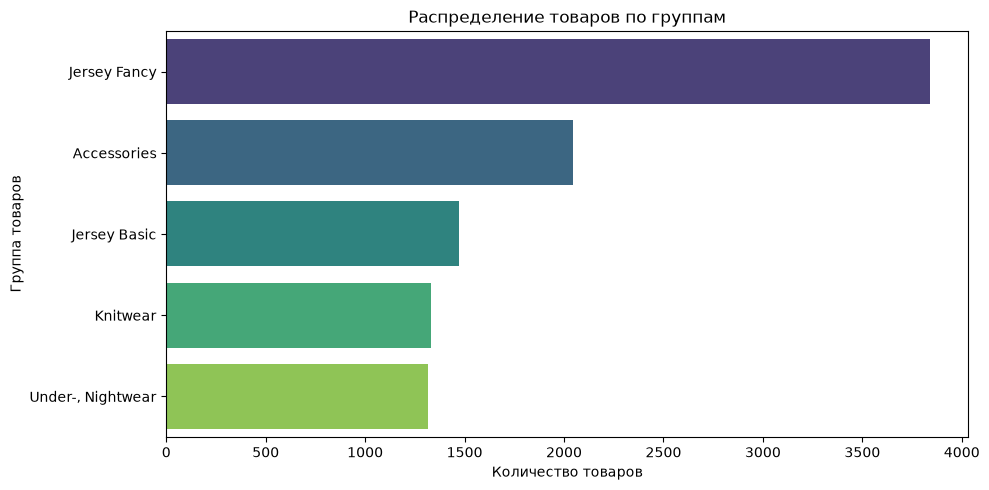

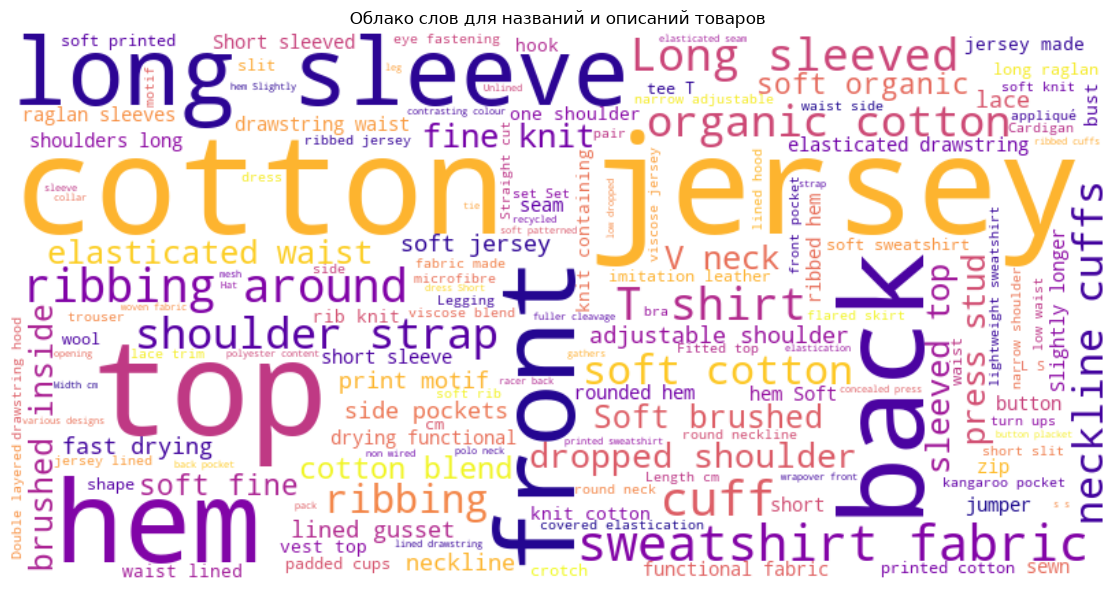

In [5]:
# 1. Проверка пропусков в финальном датафрейме
print("Пропуски в финальном датафрейме:")
print(df_final.isnull().sum())

# 2. Распределение классов (визуализация)
plt.figure(figsize=(10, 5))
sns.countplot(data=df_final, y='garment_group_name', order=df_final['garment_group_name'].value_counts().index, palette='viridis')
plt.title('Распределение товаров по группам')
plt.xlabel('Количество товаров')
plt.ylabel('Группа товаров')
plt.tight_layout()
plt.show()

# 3. Облако слов для объединенных текстов (визуализация)
df_final['text'] = df_final['prod_name'] + " " + df_final['detail_desc']

# Объединяем все тексты в одну большую строку
all_text = " ".join(df_final['text'])

# Создаем облако слов
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='plasma', max_words=150).generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако слов для названий и описаний товаров')
plt.tight_layout()
plt.show()

In [ ]:
X = df_final['text']
y = df_final['garment_group_name']

# Кодируем метки (превращаем их в числа)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Разделяем данные на обучающую и тестовую выборки (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")
print("Метки классов:", le.classes_)

Размер обучающей выборки: 8000
Размер тестовой выборки: 2000
Метки классов: ['Accessories' 'Jersey Basic' 'Jersey Fancy' 'Knitwear'
 'Under-, Nightwear']


In [7]:
# Стратегия 'most_frequent' всегда предсказывает самый частый класс
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("Результаты DummyClassifier:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dummy):.4f}")
print(classification_report(y_test, y_pred_dummy, target_names=le.classes_))

Результаты DummyClassifier:
Accuracy: 0.3840
                   precision    recall  f1-score   support

      Accessories       0.00      0.00      0.00       409
     Jersey Basic       0.00      0.00      0.00       294
     Jersey Fancy       0.38      1.00      0.55       768
         Knitwear       0.00      0.00      0.00       266
Under-, Nightwear       0.00      0.00      0.00       263

         accuracy                           0.38      2000
        macro avg       0.08      0.20      0.11      2000
     weighted avg       0.15      0.38      0.21      2000



d:\ANACONDAV4\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\ANACONDAV4\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\ANACONDAV4\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
lr = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)

# Прогнозирование на тестовой выборке
y_pred_lr = lr.predict(X_test_tfidf)

print("\nРезультаты TF-IDF + LogisticRegression:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))


Результаты TF-IDF + LogisticRegression:
Accuracy: 0.9295
                   precision    recall  f1-score   support

      Accessories       0.99      0.99      0.99       409
     Jersey Basic       0.94      0.76      0.84       294
     Jersey Fancy       0.88      0.96      0.92       768
         Knitwear       0.95      0.94      0.94       266
Under-, Nightwear       0.98      0.93      0.95       263

         accuracy                           0.93      2000
        macro avg       0.95      0.91      0.93      2000
     weighted avg       0.93      0.93      0.93      2000



In [22]:
# Установка PyTorch (легче устанавливается)
!pip install torch torchvision

# Проверка установки
import torch
print(f"PyTorch версия: {torch.__version__}")

   ---------------------------------------- 0.0/124.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.1 MB ? eta -:--:--
   ---------------------------------------- 1.3/124.1 MB 5.8 MB/s eta 0:00:22
   - -------------------------------------- 5.8/124.1 MB 14.2 MB/s eta 0:00:09
   ----- ---------------------------------- 16.5/124.1 MB 27.6 MB/s eta 0:00:04
   --------- ------------------------------ 29.1/124.1 MB 36.4 MB/s eta 0:00:03
   ------------ --------------------------- 37.5/124.1 MB 37.3 MB/s eta 0:00:03
   -------------- ------------------------- 45.4/124.1 MB 37.7 MB/s eta 0:00:03
   ---------------- ----------------------- 49.8/124.1 MB 35.6 MB/s eta 0:00:03
   ----------------- ---------------------- 53.2/124.1 MB 33.3 MB/s eta 0:00:03
   ----------------- ---------------------- 55.6/124.1 MB 30.9 MB/s eta 0:00:03
   ------------------ --------------------- 58.2/124.1 MB 28.8 MB/s eta 0:00:03
   ------------------- -------------------- 60.6/124.1 MB 27.

In [23]:
# Импорты для MLPClassifier
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json

print("Библиотеки импортированы!")

# Подготовка данных (используем уже готовые X_train, X_test, y_train, y_test)
# Если их нет, создаем заново
if 'X_train' not in locals():
    # Используем данные из предыдущих шагов
    X = df_final['text']
    y = df_final['garment_group_name']
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

print(f"Размер обучающей выборки: {len(X_train)}")
print(f"Размер тестовой выборки: {len(X_test)}")
print(f"Количество классов: {len(le.classes_)}")
print(f"Классы: {le.classes_}")

# TF-IDF векторизация
tfidf = TfidfVectorizer(max_features=10000, stop_words='english', ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Размер TF-IDF матрицы: {X_train_tfidf.shape}")

# MLPClassifier (нейросеть на sklearn)
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),  # 3 скрытых слоя
    activation='relu',
    solver='adam',
    alpha=0.001,  # L2 регуляризация
    batch_size=64,
    learning_rate='adaptive',
    max_iter=100,
    random_state=42,
    verbose=True,
    early_stopping=True,
    validation_fraction=0.1
)

print("\nОбучение MLPClassifier...")
mlp.fit(X_train_tfidf, y_train)

# Предсказания
y_pred_mlp = mlp.predict(X_test_tfidf)

# Метрики
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
f1_mlp = f1_score(y_test, y_pred_mlp, average='macro')

print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ MLPClassifier")
print("="*50)
print(f"Accuracy: {accuracy_mlp:.4f}")
print(f"Macro-F1: {f1_mlp:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_mlp, target_names=le.classes_))

Библиотеки импортированы!
Размер обучающей выборки: 8000
Размер тестовой выборки: 2000
Количество классов: 5
Классы: ['Accessories' 'Jersey Basic' 'Jersey Fancy' 'Knitwear'
 'Under-, Nightwear']
Размер TF-IDF матрицы: (8000, 10000)

Обучение MLPClassifier...
Iteration 1, loss = 0.87064370
Validation score: 0.912500
Iteration 2, loss = 0.15059331
Validation score: 0.931250
Iteration 3, loss = 0.06134792
Validation score: 0.935000
Iteration 4, loss = 0.02920833
Validation score: 0.935000
Iteration 5, loss = 0.01675951
Validation score: 0.933750
Iteration 6, loss = 0.01233467
Validation score: 0.933750
Iteration 7, loss = 0.01101436
Validation score: 0.930000
Iteration 8, loss = 0.00858101
Validation score: 0.931250
Iteration 9, loss = 0.00811037
Validation score: 0.935000
Iteration 10, loss = 0.00778106
Validation score: 0.935000
Iteration 11, loss = 0.00764385
Validation score: 0.928750
Iteration 12, loss = 0.00705593
Validation score: 0.930000
Iteration 13, loss = 0.00695667
Validation

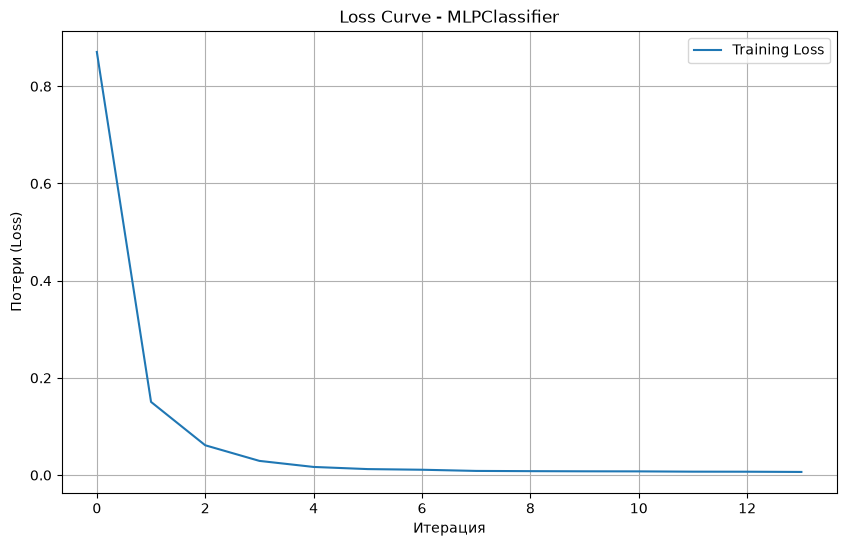

Финальные потери: 0.0065


In [24]:
# Для MLPClassifier мы можем визуализировать функцию потерь
plt.figure(figsize=(10, 6))
plt.plot(mlp.loss_curve_, label='Training Loss')
plt.title('Loss Curve - MLPClassifier')
plt.xlabel('Итерация')
plt.ylabel('Потери (Loss)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Финальные потери: {mlp.loss_:.4f}")


СРАВНЕНИЕ МОДЕЛЕЙ
Logistic Regression:
  - Accuracy: 0.9295
  - Macro-F1: 0.9274

MLPClassifier:
  - Accuracy: 0.9400
  - Macro-F1: 0.9404

✅ MLPClassifier лучше на 1.13%


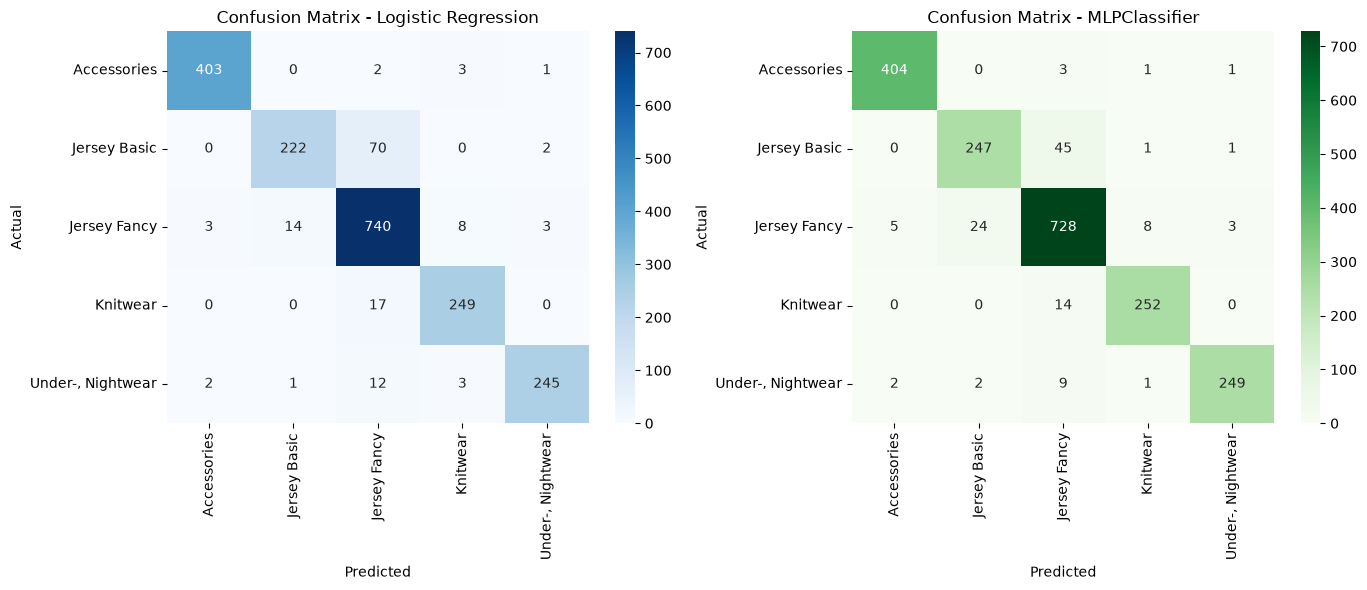

In [25]:
# Сравнение моделей
# LogisticRegression уже обучена из предыдущего шага (y_pred_lr)
# Если нет, обучим ее заново

if 'y_pred_lr' not in locals():
    from sklearn.linear_model import LogisticRegression
    lr = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
    lr.fit(X_train_tfidf, y_train)
    y_pred_lr = lr.predict(X_test_tfidf)
    accuracy_lr = accuracy_score(y_test, y_pred_lr)
    f1_lr = f1_score(y_test, y_pred_lr, average='macro')
else:
    accuracy_lr = accuracy_score(y_test, y_pred_lr)
    f1_lr = f1_score(y_test, y_pred_lr, average='macro')

print("\n" + "="*50)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*50)
print(f"Logistic Regression:")
print(f"  - Accuracy: {accuracy_lr:.4f}")
print(f"  - Macro-F1: {f1_lr:.4f}")
print(f"\nMLPClassifier:")
print(f"  - Accuracy: {accuracy_mlp:.4f}")
print(f"  - Macro-F1: {f1_mlp:.4f}")

if accuracy_mlp > accuracy_lr:
    improvement = (accuracy_mlp - accuracy_lr) / accuracy_lr * 100
    print(f"\n✅ MLPClassifier лучше на {improvement:.2f}%")
else:
    print(f"\nℹ️ Logistic Regression лучше или сопоставима")

# Матрицы ошибок
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix - Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# MLPClassifier
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('Confusion Matrix - MLPClassifier')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [26]:
# Находим ошибочные предсказания для MLPClassifier
errors_mlp = []
for i in range(len(y_test)):
    if y_test[i] != y_pred_mlp[i]:
        # Получаем вероятности для каждого класса
        probs = mlp.predict_proba(X_test_tfidf[i:i+1])[0]
        errors_mlp.append({
            'text': X_test.iloc[i],
            'true_class': le.classes_[y_test[i]],
            'pred_class': le.classes_[y_pred_mlp[i]],
            'confidence': np.max(probs),
            'all_probs': dict(zip(le.classes_, probs))
        })

# Сортируем по уверенности модели
errors_sorted = sorted(errors_mlp, key=lambda x: x['confidence'], reverse=True)

print("\n" + "="*50)
print("ТОП-3 ОШИБОЧНЫХ ПРЕДСКАЗАНИЙ MLPClassifier")
print("="*50)
for i, error in enumerate(errors_sorted[:3], 1):
    print(f"\nОшибка #{i}:")
    print(f"Текст: {error['text'][:200]}...")
    print(f"Истинный класс: {error['true_class']}")
    print(f"Предсказанный класс: {error['pred_class']}")
    print(f"Уверенность модели: {error['confidence']:.4f}")
    print("Распределение вероятностей:")
    for cls, prob in sorted(error['all_probs'].items(), key=lambda x: x[1], reverse=True):
        print(f"  {cls}: {prob:.4f}")
    print("-"*50)


ТОП-3 ОШИБОЧНЫХ ПРЕДСКАЗАНИЙ MLPClassifier

Ошибка #1:
Текст: Dora Padded top Nursing top in soft, organic cotton jersey with narrow adjustable shoulder straps. Soft integral top with functional fastening for easier nursing access, padded inserts and an elastica...
Истинный класс: Under-, Nightwear
Предсказанный класс: Jersey Fancy
Уверенность модели: 0.9990
Распределение вероятностей:
  Jersey Fancy: 0.9990
  Under-, Nightwear: 0.0008
  Jersey Basic: 0.0001
  Knitwear: 0.0001
  Accessories: 0.0000
--------------------------------------------------

Ошибка #2:
Текст: JACKIE TEE Wide top in soft cotton and modal jersey with short dolman sleeves. Rounded and slightly longer at the back....
Истинный класс: Jersey Basic
Предсказанный класс: Jersey Fancy
Уверенность модели: 0.9987
Распределение вероятностей:
  Jersey Fancy: 0.9987
  Under-, Nightwear: 0.0006
  Knitwear: 0.0004
  Jersey Basic: 0.0003
  Accessories: 0.0000
--------------------------------------------------

Ошибка #3:
Текст:

In [27]:
# Сохранение всех компонентов
import pickle
import json

# 1. Сохраняем MLPClassifier
with open('mlp_classifier.pickle', 'wb') as handle:
    pickle.dump(mlp, handle, protocol=pickle.HIGHEST_PROTOCOL)

# 2. Сохраняем TF-IDF векторизатор
with open('tfidf_vectorizer.pickle', 'wb') as handle:
    pickle.dump(tfidf, handle, protocol=pickle.HIGHEST_PROTOCOL)

# 3. Сохраняем LabelEncoder
with open('label_encoder.pickle', 'wb') as handle:
    pickle.dump(le, handle, protocol=pickle.HIGHEST_PROTOCOL)

# 4. Сохраняем метрики
metrics = {
    'logistic_regression': {
        'accuracy': float(accuracy_lr),
        'macro_f1': float(f1_lr)
    },
    'mlp_classifier': {
        'accuracy': float(accuracy_mlp),
        'macro_f1': float(f1_mlp)
    }
}

with open('model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=4)

print("\n✅ Все компоненты сохранены:")
print("  - mlp_classifier.pickle")
print("  - tfidf_vectorizer.pickle")
print("  - label_encoder.pickle")
print("  - model_metrics.json")


✅ Все компоненты сохранены:
  - mlp_classifier.pickle
  - tfidf_vectorizer.pickle
  - label_encoder.pickle
  - model_metrics.json
